# RFI analysis of 1GHz to 1.5GHz

In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd

def k(x):
    return x*1000

def M(x):
    return x*1e6

def G(x):
    return x*1e9

In [2]:
def gaussian_kernel(x, xi, h):
    return np.exp(-0.5 * ((x - xi) / h) ** 2) / (h * np.sqrt(2 * np.pi))

def epanechnikov_kernel(x, xi, h):
    u = (x - xi) / h
    kernel_value = 0.75 * (1 - u**2) * (np.abs(u) <= 1)
    return kernel_value / h

def kernel_regression(X_train, y_train, x_query, h, num_neighbors=10, x_min=0, x_max=None, kernel_type='Gaussian'):
    if x_max is None:
        x_max = X_train.max()
    
    # Only consider the nearest neighbors for the kernel regression
    X_neighbors = np.arange(x_query - num_neighbors, x_query + num_neighbors)
    X_neighbors = X_neighbors[(X_neighbors >= x_min) & (X_neighbors < x_max)]
    
    y_neighbors = y_train[X_neighbors]  # Adjust indexing for the slice
    
    # Compute the weights for the neighbors
    if kernel_type=='Gaussian':
        weights = np.array([gaussian_kernel(x_query, xi, h) for xi in X_neighbors])
    else:
        weights = np.array([epanechnikov_kernel(x_query, xi, h) for xi in X_neighbors])
    weights /= weights.sum()  # Normalize the weights
    
    # Return the weighted sum of the nearest neighbors' responses
    return np.nansum(weights * y_neighbors)

In [3]:
file = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T10.sigmf-data'
file_2 = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T20.sigmf-data'
meta = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T10.sigmf-meta'
data = np.memmap(file, dtype='f4', mode='r')
data_2 = np.memmap(file_2, dtype='f4', mode='r')

with open(meta) as m:
    m = json.load(m)

data = data.reshape(-1, 600000)
data = data + np.abs(np.min(data))

data_2 = data_2.reshape(-1, 600000)
data_2 = data_2 + np.abs(np.min(data_2))

min_f = m['global']['antenna:low_frequency']
max_f = m['global']['antenna:high_frequency']
rate = m['global']['core:sample_rate']
period = 1/ rate
f_resolution = (max_f - min_f) / k(600)

print(f"Min Frequency: {min_f/1e6} MHz")
print(f"Max Frequency: {max_f/1e6} MHz")
print(f"Sample Rate: {rate/1e6} MHz")
print(f"Period: {period} s")
print(f"Frequency Resolution: {f_resolution/1e6} MHz")

def convert_frequency_to_index(f):
    """ Function which converts input frequency in MHz to index,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using inverse of
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']

    return int((f*1e6 - min_f)*k(600)/(max_f-min_f))

def convert_index_to_frequency(i):
    """ Function which converts input index to frequency in MHz,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']   
    return (i*(max_f-min_f)/k(600) + min_f)/1e6

Min Frequency: 20.0 MHz
Max Frequency: 6000.0 MHz
Sample Rate: 1.3333333333333332e-06 MHz
Period: 0.75 s
Frequency Resolution: 0.009966666666666665 MHz


In [4]:
data.shape

(4800, 600000)

### The RFI Monitor cycles peridocially, cut data during the calibration cycle

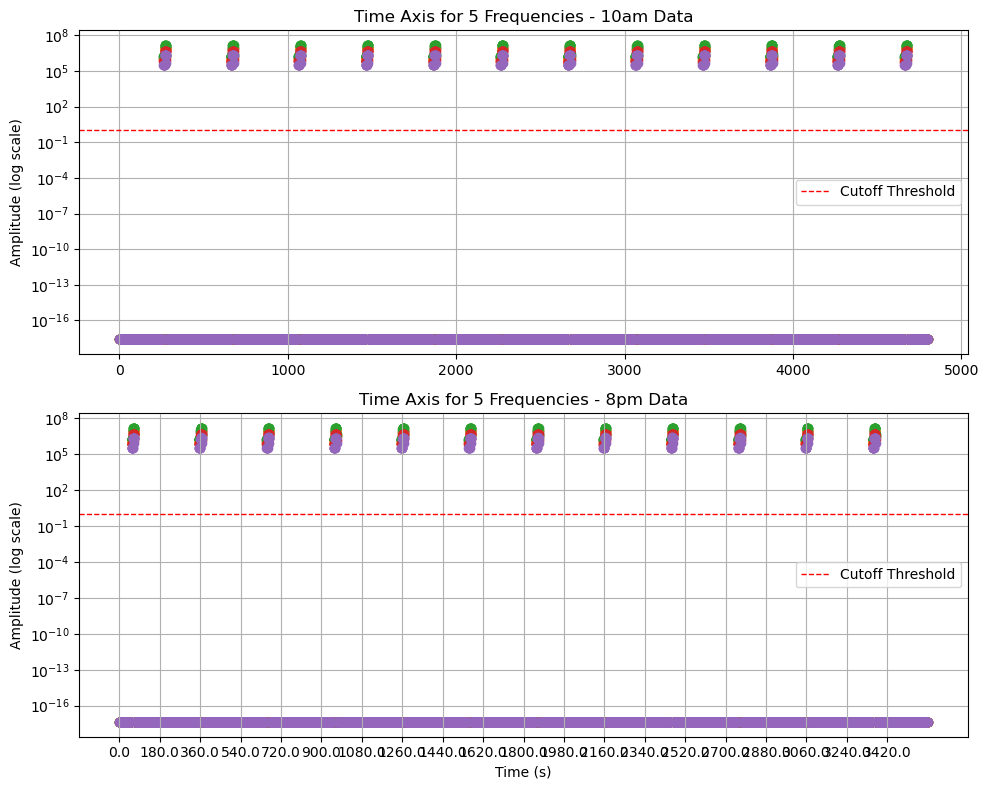

In [5]:
t1 = 0
t2 = 4800

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top plot - data (10am)
for i in range(100, 600, 100):
    ax1.scatter(np.arange(t1, t2), data[np.arange(t1, t2), k(i)])
ax1.axhline(y=1, color='r', linestyle='--', linewidth=1, label='Cutoff Threshold')
ax1.set_title("Time Axis for 5 Frequencies - 10am Data")
ax1.set_yscale('log')
ax1.set_ylabel("Amplitude (log scale)")
ax1.grid(True)
ax1.legend()

# Bottom plot - data_2 (8pm)
for i in range(100, 600, 100):
    ax2.scatter(np.arange(t1, t2), data_2[t1:t2, k(i)])
ax2.axhline(y=1, color='r', linestyle='--', linewidth=1, label='Cutoff Threshold')
ax2.set_title("Time Axis for 5 Frequencies - 8pm Data")
ax2.set_yscale('log')
ax2.set_xlabel("Time (s)")
tick_idx = np.arange(t1, t2, 240)
ax2.set_xticks(tick_idx)
ax2.set_xticklabels(np.round(tick_idx * period, 1))
ax2.set_ylabel("Amplitude (log scale)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

data_10am = np.where(data > 1, np.nan, data)
data_8pm = np.where(data_2 > 1, np.nan, data_2)

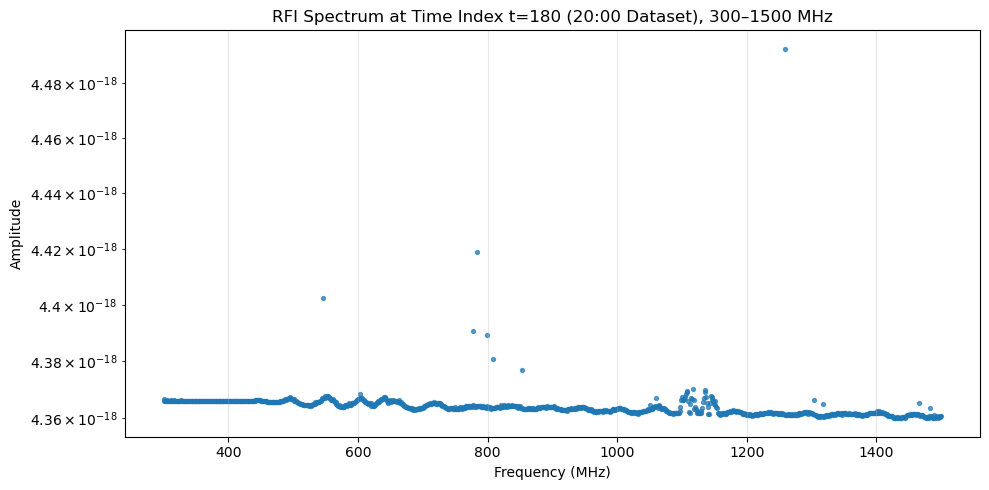

In [9]:
t = 180
f_1 = 300 # MHz
f_2 = 1500 # MHz
n = 1000
f = np.linspace(convert_frequency_to_index(f_1), convert_frequency_to_index(f_2), n)

plt.figure(figsize=(10, 5))
plt.scatter(np.linspace(f_1, f_2, n), data_2[t, f.astype(int)], s=8, alpha=0.7)
plt.yscale('log')
plt.title(f"RFI Spectrum at Time Index t={t} (20:00 Dataset), {f_1}–{f_2} MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()

## Large scale picture from 1000-1500 MHz range with kernel regression to fit a baseline value.

In [24]:
min_t = 0
max_t = 4800 - 1
n_t = 10000
index_range = np.unique(np.linspace(min_t, max_t, n_t).astype(int))

min_f = 300
max_f = 1500
n_f = 1000

min_f_index = convert_frequency_to_index(min_f)
max_f_index = convert_frequency_to_index(max_f)
freq_i_range = np.unique(np.linspace(min_f_index, max_f_index, n_f).astype(int))
freq_range = np.linspace(min_f, max_f, n_f)


# slice out the block we want to summarize (shape: n_t x n_f)
data_slice_10am = data_10am[np.ix_(index_range, freq_i_range)]
data_slice_8pm = data_8pm[np.ix_(index_range, freq_i_range)]

compressed_data_10am = pd.DataFrame({
    "index": freq_i_range, "frequency": freq_range,
    "mean": np.nanmean(data_slice_10am, axis=0),
    "std": np.nanstd(data_slice_10am, axis=0)})
compressed_data_8pm = pd.DataFrame({
    "index": freq_i_range, "frequency": freq_range,
    "mean": np.nanmean(data_slice_8pm, axis=0),
    "std": np.nanstd(data_slice_8pm, axis=0)})

i = 1
for j in np.linspace(min_t, max_t, 20).astype(int):
    compressed_data_10am[f'trace_{i}'] = data_10am[j, freq_i_range]
    compressed_data_8pm[f'trace_{i}'] = data_8pm[j, freq_i_range]
    i += 1

compressed_data_10am.head(10)


,index,frequency,mean,std,trace_1,trace_2,trace_3,trace_4,trace_5,trace_6,...,trace_11,trace_12,trace_13,trace_14,trace_15,trace_16,trace_17,trace_18,trace_19,trace_20
0,28093,300.000000,2.615941e-18,3.451237e-22,2.615777e-18,2.615796e-18,2.616098e-18,2.615807e-18,2.615859e-18,2.615786e-18,...,2.615810e-18,2.615786e-18,2.615993e-18,2.615832e-18,2.615781e-18,2.615900e-18,2.617707e-18,2.615763e-18,2.615945e-18,2.615994e-18
1,28213,301.201201,2.615685e-18,6.483746e-23,2.615753e-18,2.615748e-18,2.615752e-18,2.615754e-18,2.615747e-18,2.615748e-18,...,2.615749e-18,2.615750e-18,2.615756e-18,2.615756e-18,2.615750e-18,2.615751e-18,2.615755e-18,2.615754e-18,2.615758e-18,2.615754e-18
2,28334,302.402402,2.615685e-18,6.483746e-23,2.615751e-18,2.615746e-18,2.615757e-18,2.615761e-18,2.615747e-18,2.615756e-18,...,2.615751e-18,2.615749e-18,2.615747e-18,2.615753e-18,2.615755e-18,2.615749e-18,2.615751e-18,2.615755e-18,2.615753e-18,2.615747e-18
3,28454,303.603604,2.615685e-18,6.483746e-23,2.615751e-18,2.615747e-18,2.615750e-18,2.615759e-18,2.615746e-18,2.615749e-18,...,2.615749e-18,2.615753e-18,2.615747e-18,2.615748e-18,2.615751e-18,2.615750e-18,2.615754e-18,2.615755e-18,2.615757e-18,2.615747e-18
4,28575,304.804805,2.615761e-18,1.058791e-22,2.615788e-18,2.615830e-18,2.615864e-18,2.615813e-18,2.615840e-18,2.615783e-18,...,2.616003e-18,2.615782e-18,2.615831e-18,2.615809e-18,2.615807e-18,2.615880e-18,2.616023e-18,2.615768e-18,2.615858e-18,2.615851e-18
5,28695,306.006006,2.615685e-18,6.483746e-23,2.615749e-18,2.615751e-18,2.615755e-18,2.615755e-18,2.615753e-18,2.615749e-18,...,2.615757e-18,2.615750e-18,2.615755e-18,2.615756e-18,2.615754e-18,2.615750e-18,2.615757e-18,2.615752e-18,2.615756e-18,2.615751e-18
6,28816,307.207207,2.615685e-18,6.483746e-23,2.615755e-18,2.615755e-18,2.615755e-18,2.615758e-18,2.615754e-18,2.615758e-18,...,2.615753e-18,2.615755e-18,2.615757e-18,2.615752e-18,2.615754e-18,2.615751e-18,2.615755e-18,2.615755e-18,2.615757e-18,2.615759e-18
7,28936,308.408408,2.615685e-18,6.483746e-23,2.615755e-18,2.615755e-18,2.615753e-18,2.615754e-18,2.615748e-18,2.615758e-18,...,2.615753e-18,2.615752e-18,2.615755e-18,2.615744e-18,2.615754e-18,2.615756e-18,2.615756e-18,2.615755e-18,2.615751e-18,2.615751e-18
8,29057,309.609610,2.615685e-18,7.486784e-23,2.615750e-18,2.615756e-18,2.615752e-18,2.615754e-18,2.615748e-18,2.615755e-18,...,2.615757e-18,2.615757e-18,2.615757e-18,2.615756e-18,2.615759e-18,2.615756e-18,2.615757e-18,2.615759e-18,2.615759e-18,2.615751e-18
9,29177,310.810811,2.615685e-18,7.486784e-23,2.615752e-18,2.615758e-18,2.615750e-18,2.615762e-18,2.615752e-18,2.615753e-18,...,2.615754e-18,2.615760e-18,2.615762e-18,2.615757e-18,2.615757e-18,2.615762e-18,2.615750e-18,2.615757e-18,2.615756e-18,2.615754e-18


In [28]:
compressed_data_8pm.head(10)

,index,frequency,mean,std,trace_1,trace_2,trace_3,trace_4,trace_5,trace_6,...,trace_11,trace_12,trace_13,trace_14,trace_15,trace_16,trace_17,trace_18,trace_19,trace_20
0,28093,300.000000,4.366172e-18,2.214621e-22,4.366143e-18,4.366382e-18,4.366331e-18,4.366268e-18,4.366241e-18,4.366133e-18,...,4.366125e-18,4.366132e-18,4.366541e-18,NaN,4.366241e-18,4.366136e-18,4.366180e-18,4.366274e-18,4.366282e-18,4.366149e-18
1,28213,301.201201,4.366066e-18,3.743392e-23,4.366105e-18,4.366095e-18,4.366102e-18,4.366102e-18,4.366100e-18,4.366098e-18,...,4.366098e-18,4.366104e-18,4.366101e-18,NaN,4.366095e-18,4.366086e-18,4.366101e-18,4.366098e-18,4.366097e-18,4.366100e-18
2,28334,302.402402,4.366066e-18,3.743392e-23,4.366095e-18,4.366099e-18,4.366100e-18,4.366100e-18,4.366101e-18,4.366101e-18,...,4.366104e-18,4.366103e-18,4.366107e-18,NaN,4.366106e-18,4.366104e-18,4.366102e-18,4.366098e-18,4.366100e-18,4.366103e-18
3,28454,303.603604,4.366066e-18,3.743392e-23,4.366101e-18,4.366102e-18,4.366109e-18,4.366100e-18,4.366099e-18,4.366096e-18,...,4.366099e-18,4.366098e-18,4.366102e-18,NaN,4.366101e-18,4.366091e-18,4.366100e-18,4.366096e-18,4.366090e-18,4.366095e-18
4,28575,304.804805,4.366105e-18,9.904085e-23,4.366132e-18,4.366241e-18,4.366231e-18,4.366183e-18,4.366239e-18,4.366183e-18,...,4.366122e-18,4.366141e-18,4.366268e-18,NaN,4.366221e-18,4.366159e-18,4.366189e-18,4.366220e-18,4.366286e-18,4.366158e-18
5,28695,306.006006,4.366068e-18,3.743392e-23,4.366100e-18,4.366100e-18,4.366184e-18,4.366106e-18,4.366098e-18,4.366102e-18,...,4.366103e-18,4.366102e-18,4.366105e-18,NaN,4.366100e-18,4.366093e-18,4.366107e-18,4.366097e-18,4.366103e-18,4.366095e-18
6,28816,307.207207,4.366068e-18,3.743392e-23,4.366102e-18,4.366102e-18,4.366203e-18,4.366107e-18,4.366100e-18,4.366116e-18,...,4.366106e-18,4.366102e-18,4.366111e-18,NaN,4.366104e-18,4.366130e-18,4.366100e-18,4.366093e-18,4.366103e-18,4.366107e-18
7,28936,308.408408,4.366068e-18,3.743392e-23,4.366103e-18,4.366103e-18,4.366207e-18,4.366107e-18,4.366103e-18,4.366100e-18,...,4.366099e-18,4.366107e-18,4.366098e-18,NaN,4.366102e-18,4.366095e-18,4.366102e-18,4.366096e-18,4.366104e-18,4.366103e-18
8,29057,309.609610,4.366068e-18,3.743392e-23,4.366104e-18,4.366102e-18,4.366204e-18,4.366107e-18,4.366106e-18,4.366105e-18,...,4.366105e-18,4.366110e-18,4.366102e-18,NaN,4.366102e-18,4.366107e-18,4.366108e-18,4.366100e-18,4.366104e-18,4.366104e-18
9,29177,310.810811,4.366068e-18,3.743392e-23,4.366104e-18,4.366101e-18,4.366199e-18,4.366107e-18,4.366102e-18,4.366103e-18,...,4.366101e-18,4.366104e-18,4.366104e-18,NaN,4.366102e-18,4.366097e-18,4.366104e-18,4.366099e-18,4.366100e-18,4.366099e-18


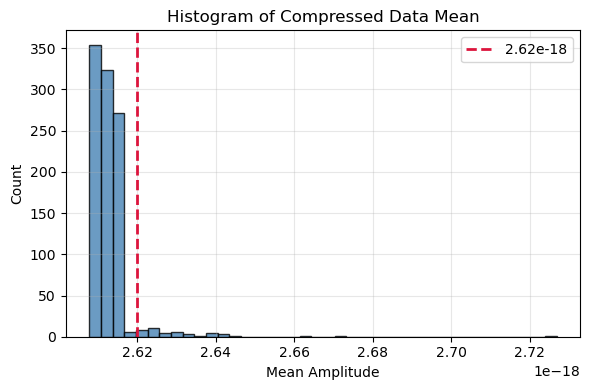

In [25]:
plt.figure(figsize=(6, 4))
plt.hist(compressed_data_10am["mean"], bins=40, color="steelblue", edgecolor="black", alpha=0.8)
cutoff_value = 2.62e-18
#plt.xscale("log")
plt.title("Histogram of Compressed Data Mean")
plt.xlabel("Mean Amplitude")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.axvline(cutoff_value, color="crimson", linestyle="--", linewidth=2, label=f"{cutoff_value}")
plt.legend()
plt.show()

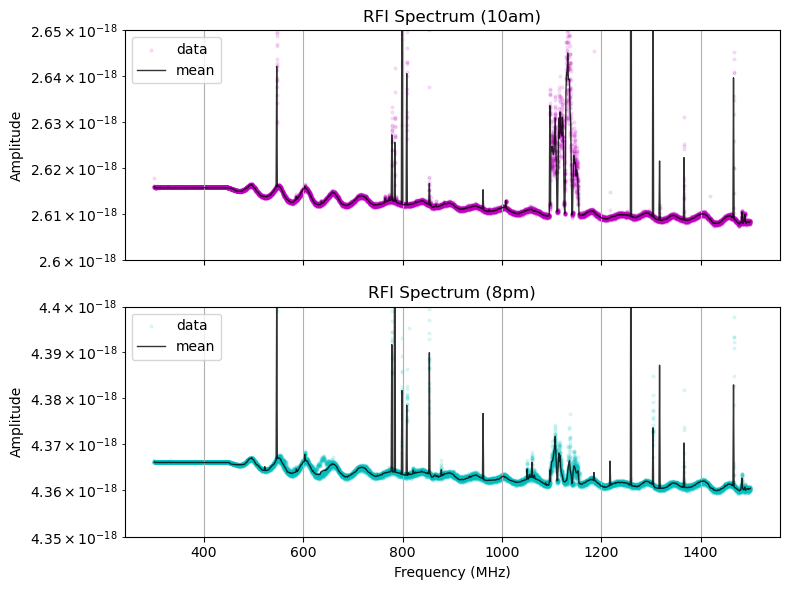

In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Top subplot: 10am
for j in range(1, 20):
    ax1.scatter(
        freq_range,
        compressed_data_10am[f"trace_{j}"],
        c="m", s=4, alpha=0.1,
        label="data" if j == 1 else None
    )
ax1.plot(
    freq_range,
    compressed_data_10am["mean"],
    label="mean",
    color="black",
    linestyle="-",
    linewidth=1,
    alpha=0.8
)
ax1.set_title("RFI Spectrum (10am)")
ax1.set_ylabel("Amplitude")
ax1.set_yscale("log")
ax1.set_ylim(2.6e-18, 2.65e-18)
ax1.grid(True)
ax1.legend()

# Bottom subplot: 8pm
for j in range(1, 20):
    ax2.scatter(
        freq_range,
        compressed_data_8pm[f"trace_{j}"],
        c="c", s=4, alpha=0.1,
        label="data" if j == 1 else None
    )
ax2.plot(
    freq_range,
    compressed_data_8pm["mean"],
    label="mean",
    color="black",
    linestyle="-",
    linewidth=1,
    alpha=0.8
)
ax2.set_title("RFI Spectrum (8pm)")
ax2.set_xlabel("Frequency (MHz)")
ax2.set_ylabel("Amplitude")
ax2.set_yscale("log")
ax2.set_ylim(4.35e-18, 4.4e-18)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig("../plots/rfi/full_spectrum_overview.png", dpi=300)
plt.show()
# plt.xlim(1000, 1200)


In [43]:
H_transitions = {
    "H186alpha": 1013.76766452,
    "H185alpha": 1030.25153147,
    "H184alpha": 1047.09471537,
    "H183alpha": 1064.30706038,
    "H182alpha": 1081.89873607,
    "H181alpha": 1099.88025005,
    "H180alpha": 1118.26246118,
    "H179alpha": 1137.05659327,
    "H178alpha": 1156.27424957,
    "H177alpha": 1175.92742772,
    "H176alpha": 1196.02853557,
    "H175alpha": 1216.59040757,
    "H174alpha": 1237.626322,
    "H173alpha": 1259.150019,
    "H172alpha": 1281.1757194,
    "H171alpha": 1303.71814445,
    "H170alpha": 1326.7925365,
    "H169alpha": 1350.41468066,
    "H168alpha": 1374.60092745,
    "H167alpha": 1399.36821658,
    "H166alpha": 1424.73410189,
    "H165alpha": 1450.71677746,
    "H164alpha": 1477.33510502,
}

In [ ]:
min_cutoff = 0
max_cutoff = cutoff_value

X_train = np.arange(len(compressed_data))
y_train = np.clip(compressed_data["mean"].to_numpy(dtype=float), min_cutoff, max_cutoff)
x_predictions = X_train
baseline = np.array([kernel_regression(X_train, y_train, X, h=15, num_neighbors=300) for X in x_predictions])
compressed_data["baseline"] = baseline

# plot mean and ±2σ
frequency_range = compressed_data["frequency"]


FileNotFoundError: [Errno 2] No such file or directory: 'rrl_images/H186alpha.png'

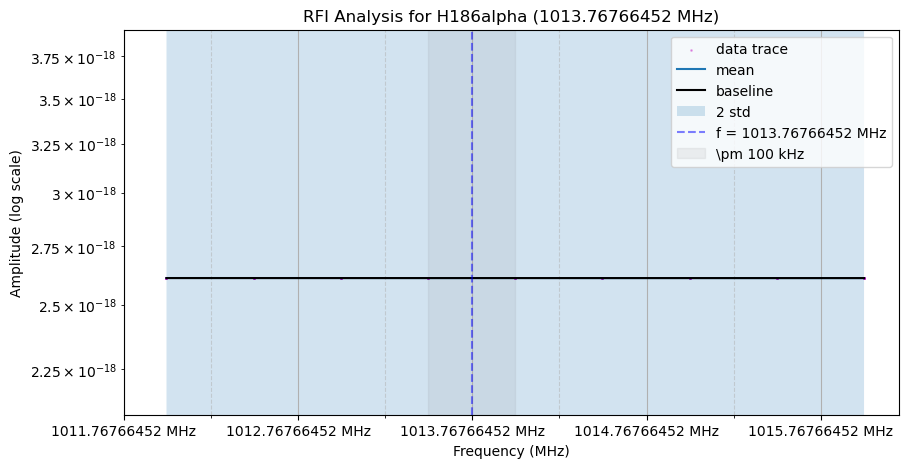

In [44]:

for transition_name, frequency in H_transitions.items():
    f = frequency
    close_range = f - 0.1, f + 0.1
    long_range = f - 2, f + 2

    closest_row = (compressed_data['frequency'] - f).abs().idxmin()
    close_min_row = (compressed_data['frequency'] - close_range[0]).abs().idxmin()
    close_max_row = (compressed_data['frequency'] - close_range[1]).abs().idxmin()
    long_min_row = (compressed_data['frequency'] - long_range[0]).abs().idxmin()
    long_max_row = (compressed_data['frequency'] - long_range[1]).abs().idxmin()

    close_id_range = range(close_min_row, close_max_row + 1)
    long_id_range = range(long_min_row, long_max_row + 1)

    frequency_range = compressed_data.loc[long_id_range, 'frequency']
    baseline = compressed_data.loc[long_id_range, 'baseline'] 
    geo_means = compressed_data.loc[long_id_range, 'mean']
    geo_stds = compressed_data.loc[long_id_range, 'std']

    y_min = np.min(compressed_data.loc[close_id_range][["baseline", "mean", "trace_1", "trace_2", "trace_3"]])*0.8
    y_max = np.max(compressed_data.loc[close_id_range][["baseline", "mean", "trace_1", "trace_2", "trace_3"]])*1.5

    plt.figure(figsize=(10,5))

    # plot a few raw traces
    for j in range(1, 10):
        plt.scatter(
            frequency_range, 
            compressed_data.loc[long_id_range, f'trace_{j}'],
            c='m', s=1, alpha=0.3, 
            label='data trace' if j==1 else None
        )

    # plot mean and ±2σ
    plt.plot(
        frequency_range, 
        geo_means,
        label='mean'
    )

    plt.plot(
        frequency_range, 
        baseline,
        label='baseline',
        color='black'
    )

    plt.fill_between(frequency_range,
                    geo_means/(geo_stds**2),
                    geo_means*(geo_stds**2),
                    alpha=0.2, label='2 std')

    plt.axvline(
        x=f, color='b', alpha=0.5, linestyle='--', label=f'f = {f} MHz')
    plt.axvspan(
        compressed_data.loc[close_min_row, "frequency"],
        compressed_data.loc[close_max_row, "frequency"],
        color='grey', alpha=0.1, label='\pm 100 kHz')


    # Set logarithmic scale for y-axis
    plt.yscale('log')

    # Set major ticks on x-axis at every 1 unit with MHz labels
    major_ticks = np.arange(long_range[0], long_range[1] + 1, 1)
    plt.xticks(ticks=major_ticks, labels=[f"{x} MHz" for x in major_ticks])

    # Enable minor ticks for both axes
    plt.minorticks_on()

    # Set minor ticks on x-axis at every 0.5 units
    minor_ticks = np.arange(long_range[0], long_range[1] + 0.5, 0.5)
    plt.gca().set_xticks(minor_ticks, minor=True)

    # Enable grid for major ticks on x-axis
    plt.grid(visible=True, which='minor', axis='x', linestyle='--', alpha=0.5)
    plt.grid(visible=True, which='major', axis='x')

    plt.legend()
    plt.title("RFI Analysis for " + transition_name + f" ({f} MHz)")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Amplitude (log scale)")

    plt.ylim(y_min, y_max)

    plt.savefig(f'rrl_images/{transition_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
